<a href="https://colab.research.google.com/github/jphysycs/PhD/blob/main/An%C3%A1lise_explorat%C3%B3ria(Efici%C3%AAncia).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import re
import requests
import pandas as pd
from datetime import datetime


def ler_rpt_github(url):
    """
    Lê um arquivo .RPT do GitHub e retorna um DataFrame
    com a tabela de picos.
    """

    # Converte URL do GitHub para RAW
    url = url.replace(
        "https://github.com/",
        "https://raw.githubusercontent.com/"
    ).replace("/blob/", "/")

    texto_response = requests.get(url)
    texto_response.raise_for_status()

    linhas = texto_response.text.splitlines()

    dados = []

    for linha in linhas:

        linha = linha.strip()

        # Split the line into parts
        partes = linha.split()

        # Skip lines that are too short to be a peak entry
        # A peak entry without 'M'/'m' has 7 numeric fields.
        # If it has 'M'/'m', it has 8 fields.
        if len(partes) < 7:
            continue

        # Determine if 'Tipo' (M/m) is present
        tipo_present = False
        if partes[0] == 'M' or partes[0] == 'm':
            tipo_present = True

        try:
            current_data = {}
            if tipo_present:
                # Line starts with 'M' or 'm', e.g., 'M 1 0.79 ...'
                if len(partes) < 8: # If 'M'/'m' is present, we expect at least 8 parts
                    continue
                current_data["Tipo"] = partes[0]
                current_data["Pico"] = int(partes[1])
                current_data["Energia_keV"] = float(partes[2])
                current_data["Resolucao_keV"] = float(partes[3])
                current_data["Background"] = float(partes[4])
                current_data["Contagens"] = float(partes[5])
                current_data["Contagens_1s"] = float(partes[6])
                current_data["Canal"] = float(partes[7])
            else:
                # Line starts directly with the peak number, e.g., '3 9.92 ...'
                current_data["Tipo"] = '' # No 'M' or 'm' prefix
                current_data["Pico"] = int(partes[0])
                current_data["Energia_keV"] = float(partes[1])
                current_data["Resolucao_keV"] = float(partes[2])
                current_data["Background"] = float(partes[3])
                current_data["Contagens"] = float(partes[4])
                current_data["Contagens_1s"] = float(partes[5])
                current_data["Canal"] = float(partes[6])

            dados.append(current_data)

        except ValueError:
            # This will catch lines that do not conform to the expected numeric format,
            # effectively filtering out non-peak header/footer lines.
            pass

    return pd.DataFrame(dados)

# Define the base URL for the repository folder up to 'Eficiencia/'
base_repo_url = "https://raw.githubusercontent.com/jphysycs/PhD/refs/heads/main/Eficiencia/"

# Define valid folders
valid_folders = ["BG", "P0", "P1", "P2", "P3", "P4", "P5", "P6", "P7"]

# Ask the user for the folder name
print(f"Please choose a folder from the following options: {', '.join(valid_folders)}")
folder_name = input("Enter the folder name: ")

# Validate the folder name
while folder_name not in valid_folders:
    print("Invalid folder name. Please choose from the provided options.")
    folder_name = input("Enter the folder name: ")

# Ask the user for the RPT filename
filename = input("Please enter the .RPT filename (e.g., 137CS148S15.RPT): ")

# Construct the full URL for the selected file
url = base_repo_url + folder_name + "/" + filename

# Fetch the raw content for the new URL and store in the global 'texto' variable
response = requests.get(url)
response.raise_for_status()
texto = response.text

# Process the raw content for date/time
lines = texto.splitlines()
for i in range(4):
    print(lines[i])

# Extract relevant lines
date_time_str = lines[1].strip()
measurement_time_str = lines[2].strip()
real_time_str = lines[3].strip()

# Parse the date and time
date_time_obj = datetime.strptime(date_time_str, '%d/%m/%Y %H:%M:%S')

# Extract numeric values for time in seconds
measurement_seconds = float(measurement_time_str.split()[0])
real_seconds = float(real_time_str.split()[0])

# Create a dictionary for the DataFrame
data_to_df = {
    'DateTime': [date_time_obj],
    'Measurement_Time_seconds': [measurement_seconds],
    'Real_Time_seconds': [real_seconds]
}

# Create the DataFrame
df_times = pd.DataFrame(data_to_df)

# Display the DataFrame
display(df_times)

# Get the peak DataFrame using the new URL
df = ler_rpt_github(url)

Please choose a folder from the following options: BG, P0, P1, P2, P3, P4, P5, P6, P7
Enter the folder name: P0
Please enter the .RPT filename (e.g., 137CS148S15.RPT): 60Co144S15.RPT
C:\GENIE2K\CAMFILES\Semmler\JP\P0\60CO144S15.CNF             
11/02/2025 11:35:32   
    6000.00 seconds
    6020.75 seconds


,DateTime,Measurement_Time_seconds,Real_Time_seconds
0,2025-02-11 11:35:32,6000.0,6020.75


In [7]:
df

,Tipo,Pico,Energia_keV,Resolucao_keV,Background,Contagens,Contagens_1s,Canal
0,,1,0.88,0.39,3365.0,50835.977,0.47,24.21
1,,2,238.57,0.90,3719.0,278.945,36.83,974.14
2,,3,510.82,1.28,2260.0,494.883,16.92,2062.18
3,,4,583.23,1.38,1972.0,268.626,28.15,2351.59
4,,5,609.39,0.88,2022.0,291.519,26.28,2456.14
5,,6,1173.41,1.55,2093.0,87896.789,0.35,4710.26
6,,7,1332.74,1.62,476.0,78590.617,0.36,5347.05
7,,8,1461.05,1.55,205.0,329.582,10.06,5859.84
8,,9,1764.82,1.77,111.0,99.220,22.02,7073.86


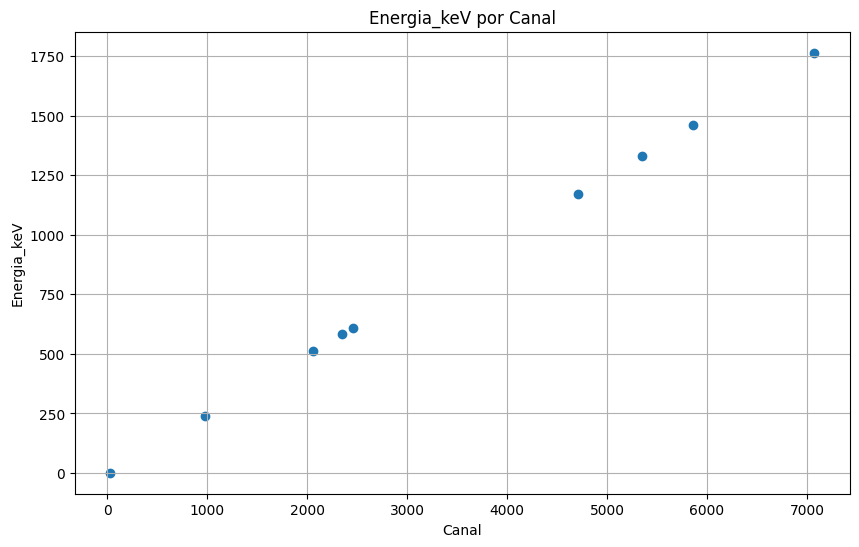

In [8]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Canal'], df['Energia_keV'])

# Add title and labels
plt.title('Energia_keV por Canal')
plt.xlabel('Canal')
plt.ylabel('Energia_keV')

# Display the plot
plt.grid(True)
plt.show()

In [9]:
df_times

,DateTime,Measurement_Time_seconds,Real_Time_seconds
0,2025-02-11 11:35:32,6000.0,6020.75
